In [ ]:
%matplotlib inline


import _plotting as plot
import jax
import jax.numpy as jnp
import matplotlib.colors

from xxm.core.align import match_states_by_conditional_mean as match_states
from xxm.slds import GaussianSLDS

In [2]:
STATES_CMAP = matplotlib.colors.ListedColormap(['tab:blue', 'tab:orange', 'tab:green'])


def make_true_model() -> GaussianSLDS:
    return GaussianSLDS.from_params(
        initial_probs=jnp.array([0.4, 0.3, 0.3]),
        transition_probs=jnp.array(
            [
                [0.97, 0.02, 0.01],
                [0.02, 0.97, 0.01],
                [0.02, 0.02, 0.96],
            ]
        ),
        latent_initial_means=jnp.zeros((3, 2)),
        latent_initial_covariances=jnp.tile(
            0.25 * jnp.eye(2),
            (3, 1, 1),
        ),
        dynamics_coefficients=jnp.array(
            [
                [[0.94, 0.22], [-0.22, 0.94]],
                [[0.94, -0.22], [0.22, 0.94]],
                [[0.98, 0.00], [0.00, 0.70]],
            ]
        ),
        dynamics_bias=jnp.zeros((3, 2)),
        dynamics_covariances=jnp.tile(
            0.03 * jnp.eye(2),
            (3, 1, 1),
        ),
        emission_coefficients=jnp.eye(2),
        emission_bias=jnp.zeros(2),
        emission_covariance=0.05 * jnp.eye(2),
    )


true_model = make_true_model()

true_states, true_latents, observations = true_model.sample(
    key=jax.random.key(0),
    num_steps=1000,
)

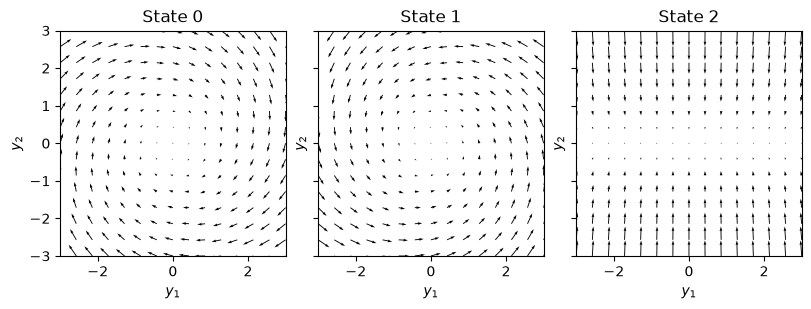

In [3]:
plot.plot_conditional_linear_dynamics(true_model.dynamics)

AR-HMM:   0%|          | 0/1000 [00:00<?, ?it/s]

Variational EM:   0%|          | 0/100 [00:00<?, ?it/s]

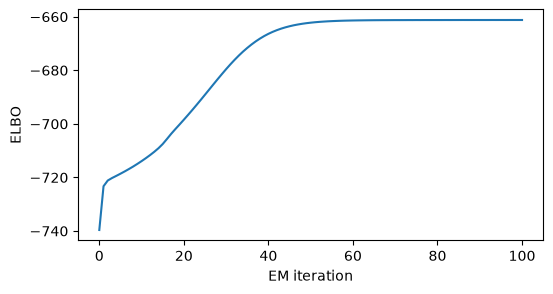

In [4]:
initial_model = GaussianSLDS.from_arhmm(
    key=jax.random.key(1),
    observations=observations,
    num_states=true_model.num_states,
    latent_dim=2,
    num_arhmm_iters=1000,
)

learned_model, elbos = initial_model.fit(
    observations,
    num_iters=100,
    num_inference_iters=20,
)

plot.plot_fit_progress(elbos, name='ELBO')

In [ ]:
posterior, elbo = learned_model.infer(observations, num_iters=50)

permutation = match_states(posterior.discrete.state_probs, true_states)
matched_model = learned_model.permute(permutation)
posterior, _ = matched_model.infer(observations, num_iters=50)

state_probs = posterior.discrete.state_probs
latent_means = posterior.continuous.means

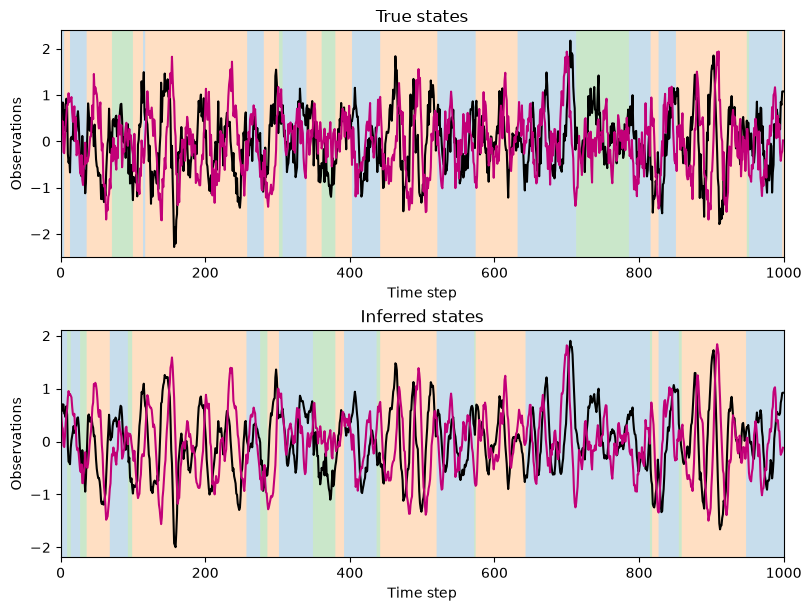

In [7]:
inferred_states = matched_model.most_likely_states(posterior)
reconstruction = matched_model.observation_mean(posterior)

plot.plot_inferred_states_comparison(
    true_states,
    observations,
    inferred_states,
    reconstruction,
)

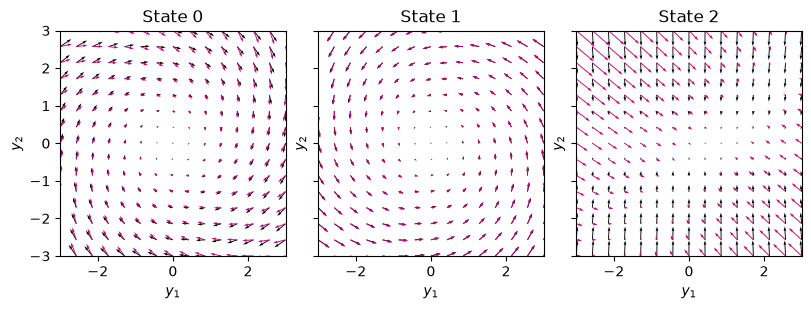

In [8]:
plot.plot_conditional_linear_dynamics_comparison(
    true_model.dynamics,
    matched_model.dynamics,
)

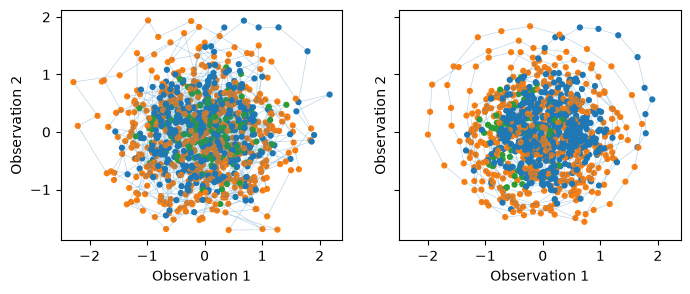

In [9]:
plot.plot_sequence_2d_comparison(
    true_states,
    observations,
    inferred_states,
    reconstruction,
)